# Predicting House Prices using Regression Techniques

### Machine Learning Project
This notebook builds a house-price prediction system using regression techniques.

**Models used:**
- Linear Regression
- Ridge Regression
- Random Forest Regressor

**Dataset:** Kaggle House Prices dataset (`train.csv`)

**Workflow:**
1. Import libraries
2. Load and inspect the dataset
3. Perform exploratory data analysis
4. Handle missing values
5. Encode categorical variables
6. Split data into training and testing sets
7. Train regression models
8. Evaluate model performance
9. Compare the models
10. Predict house prices


## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

Place the Kaggle **`train.csv`** file in the same folder as this notebook.

In [2]:
# Load dataset
file_path = "train.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Understand the Dataset

In [3]:
# Basic information
print("Dataset Information:\n")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 1

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Statistical Summary:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
# Check missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns containing missing values:")
display(missing_values.head(20))

Columns containing missing values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 4. Exploratory Data Analysis (EDA)

The target variable is **SalePrice**, which represents the final selling price of the house.

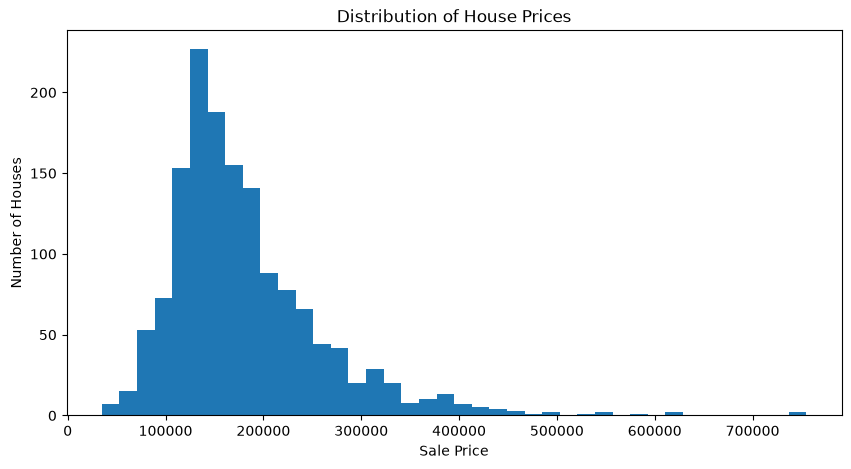

In [5]:
# Distribution of house prices
plt.figure(figsize=(10, 5))
plt.hist(df["SalePrice"], bins=40)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

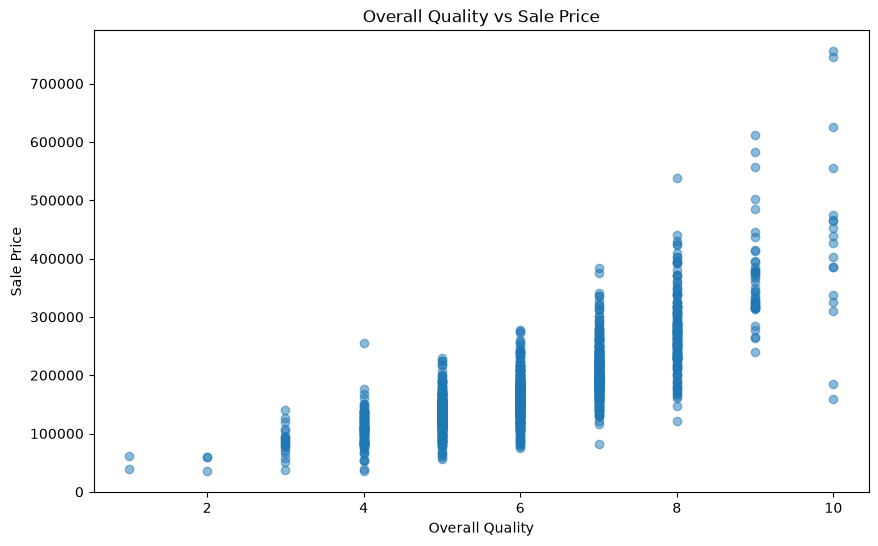

In [6]:
# SalePrice against Overall Quality
plt.figure(figsize=(10, 6))
plt.scatter(df["OverallQual"], df["SalePrice"], alpha=0.5)
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")
plt.show()

In [7]:
# Correlation of numerical features with SalePrice
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()["SalePrice"].sort_values(ascending=False)

print("Features most correlated with SalePrice:")
display(correlation.head(15))

Features most correlated with SalePrice:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

## 5. Prepare Features and Target

- **Target (`y`)** = `SalePrice`
- **Features (`X`)** = all other columns

The `Id` column is removed because it is only an identifier and does not provide meaningful predictive information.

In [8]:
# Separate features and target
X = df.drop(columns=["SalePrice", "Id"], errors="ignore")
y = df["SalePrice"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1460, 79)
Target shape: (1460,)


## 6. Identify Numerical and Categorical Features

In [9]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features[:15])

print("\nCategorical features:")
print(categorical_features[:15])

Number of numerical features: 36
Number of categorical features: 43

Numerical features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF']

Categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl']


## 7. Preprocessing

For numerical features:
- Missing values are filled using the median.
- Features are standardized for Linear and Ridge Regression.

For categorical features:
- Missing values are filled using the most frequent value.
- Categories are converted into numerical form using One-Hot Encoding.

In [10]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 8. Split the Dataset

The data is divided into:
- **80% training data**
- **20% testing data**

The training data is used to learn patterns, while the testing data evaluates performance on unseen houses.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


## 9. Train Linear Regression Model

In [12]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 10. Train Ridge Regression Model

In [13]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


## 11. Train Random Forest Regression Model

Random Forest is a tree-based ensemble method that can capture non-linear relationships between house features and prices.

In [14]:
# Separate preprocessing without scaling for the tree-based model
numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_features),
        ("cat", categorical_transformer_rf, categorical_features)
    ]
)

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 12. Evaluate the Models

We use three common regression metrics:

- **MAE (Mean Absolute Error):** Average absolute prediction error.
- **RMSE (Root Mean Squared Error):** Gives more weight to larger errors.
- **R² Score:** Measures how much of the variation in house prices is explained by the model. Higher is better.

In [15]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

results = [
    evaluate_model("Linear Regression", y_test, linear_predictions),
    evaluate_model("Ridge Regression", y_test, ridge_predictions),
    evaluate_model("Random Forest", y_test, rf_predictions)
]

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,18287.698623,29473.873055,0.886744
1,Ridge Regression,19040.559638,30646.308031,0.877555
2,Random Forest,17350.759064,28376.645804,0.895020


## 13. Compare Model Performance

,Model,MAE,RMSE,R2 Score
2,Random Forest,17350.759064,28376.645804,0.895020
0,Linear Regression,18287.698623,29473.873055,0.886744
1,Ridge Regression,19040.559638,30646.308031,0.877555


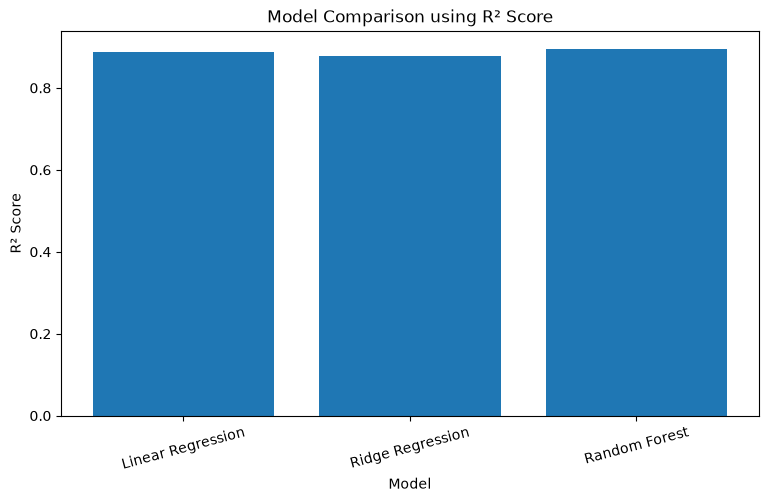

In [16]:
# Display model comparison
display(results_df.sort_values("R2 Score", ascending=False))

# R2 score comparison
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Model Comparison using R² Score")
plt.xticks(rotation=15)
plt.show()

## 14. Actual vs Predicted Prices

A good regression model should produce predictions close to the actual values. The points should therefore lie close to the diagonal reference line.

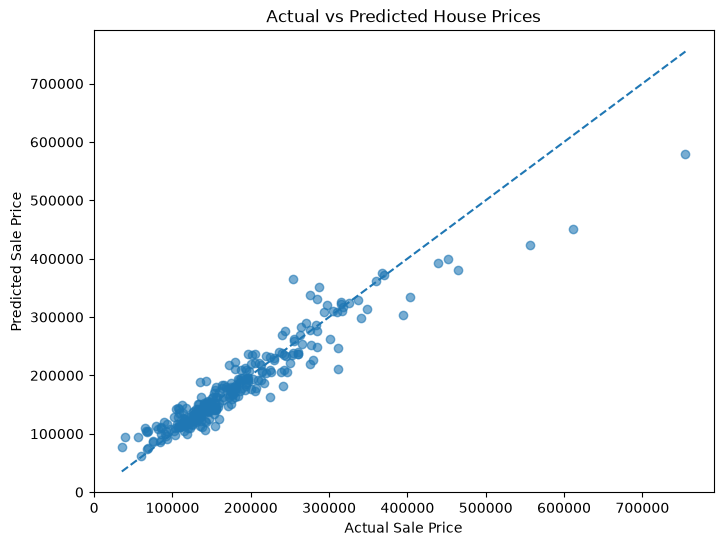

In [17]:
# Use Random Forest predictions for visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.6)

min_value = min(y_test.min(), rf_predictions.min())
max_value = max(y_test.max(), rf_predictions.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## 15. Sample Predictions

In [18]:
# Show a few actual and predicted prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": rf_predictions[:10]
})

comparison["Absolute Error"] = (
    comparison["Actual Price"] - comparison["Predicted Price"]
).abs()

comparison

,Actual Price,Predicted Price,Absolute Error
0,154500,140689.666667,13810.333333
1,325000,324020.600000,979.400000
2,115000,116395.440000,1395.440000
3,159000,153197.763333,5802.236667
4,315500,321560.876667,6060.876667
5,75500,85867.166667,10367.166667
6,311500,210936.613333,100563.386667
7,146000,152330.926667,6330.926667
8,84500,85825.330000,1325.330000
9,135500,128622.290000,6877.710000


## 16. Predict the Price of a New House

A new house can be passed to the trained Random Forest pipeline as a DataFrame containing the same feature columns as `X`.

> Keep the input columns consistent with the training dataset. This example uses the first test-row structure and modifies a few values.

In [19]:
# Example new house based on one test sample
new_house = X_test.iloc[[0]].copy()

# Example modifications (only when the corresponding columns exist)
if "OverallQual" in new_house.columns:
    new_house.loc[:, "OverallQual"] = 8

if "GrLivArea" in new_house.columns:
    new_house.loc[:, "GrLivArea"] = 2000

if "GarageCars" in new_house.columns:
    new_house.loc[:, "GarageCars"] = 2

predicted_price = rf_model.predict(new_house)[0]

print(f"Predicted House Price: ${predicted_price:,.2f}")

Predicted House Price: $231,420.62


## 17. Conclusion

This project demonstrates how regression techniques can be used to predict house prices from property-related features.

The complete machine learning pipeline includes:
- Data loading and exploration
- Missing-value treatment
- Categorical feature encoding
- Feature preprocessing
- Model training
- Performance evaluation
- Model comparison
- House-price prediction

Among the models tested, the model with the strongest test-set metrics can be selected for the final prediction task. The exact scores depend on the dataset and preprocessing environment.

## Key Learning Outcomes

1. Understand the fundamentals of regression-based prediction.
2. Learn how to preprocess mixed numerical and categorical data.
3. Compare different machine learning regression algorithms.
4. Evaluate models using MAE, RMSE, and R².
5. Build a complete end-to-end machine learning workflow in Python.
